In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

***TESLA CASE***

In [9]:
tickers = "TSLA"
tsla = yf.Ticker(tickers)
data = tsla.history(start="2025-02-01", end="2026-02-01", interval="1d")
print(data.head())

                                 Open        High         Low       Close  \
Date                                                                        
2025-02-03 00:00:00-05:00  386.679993  389.170013  374.359985  383.679993   
2025-02-04 00:00:00-05:00  382.630005  394.000000  381.399994  392.209991   
2025-02-05 00:00:00-05:00  387.510010  388.390015  375.529999  378.170013   
2025-02-06 00:00:00-05:00  373.029999  375.399994  363.179993  374.320007   
2025-02-07 00:00:00-05:00  370.190002  380.549988  360.339996  361.619995   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-02-03 00:00:00-05:00  93732100        0.0           0.0  
2025-02-04 00:00:00-05:00  57072200        0.0           0.0  
2025-02-05 00:00:00-05:00  57223300        0.0           0.0  
2025-02-06 00:00:00-05:00  77918200        0.0           0.0  
2025-02-07 00:00:00-05:00  70298300        0.0           0.0  


In [10]:
close_prices = data['Close']
df_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

                       Date       Close
0 2025-02-03 00:00:00-05:00  383.679993
1 2025-02-04 00:00:00-05:00  392.209991
2 2025-02-05 00:00:00-05:00  378.170013
3 2025-02-06 00:00:00-05:00  374.320007
4 2025-02-07 00:00:00-05:00  361.619995


In [11]:
df_close.to_csv("/tmp/tsla_close_prices.csv", index=False)


In [12]:
df_tesla = pd.read_csv("/tmp/tsla_close_prices.csv")
df_tesla.head()

,Date,Close
0,2025-02-03 00:00:00-05:00,383.679993
1,2025-02-04 00:00:00-05:00,392.209991
2,2025-02-05 00:00:00-05:00,378.170013
3,2025-02-06 00:00:00-05:00,374.320007
4,2025-02-07 00:00:00-05:00,361.619995


/var/folders/62/rh9l84sx6d70_dkrpcr4kfbr0000gn/T/ipykernel_41194/2169512425.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_tesla['Date'] = pd.to_datetime(df_tesla['Date'])


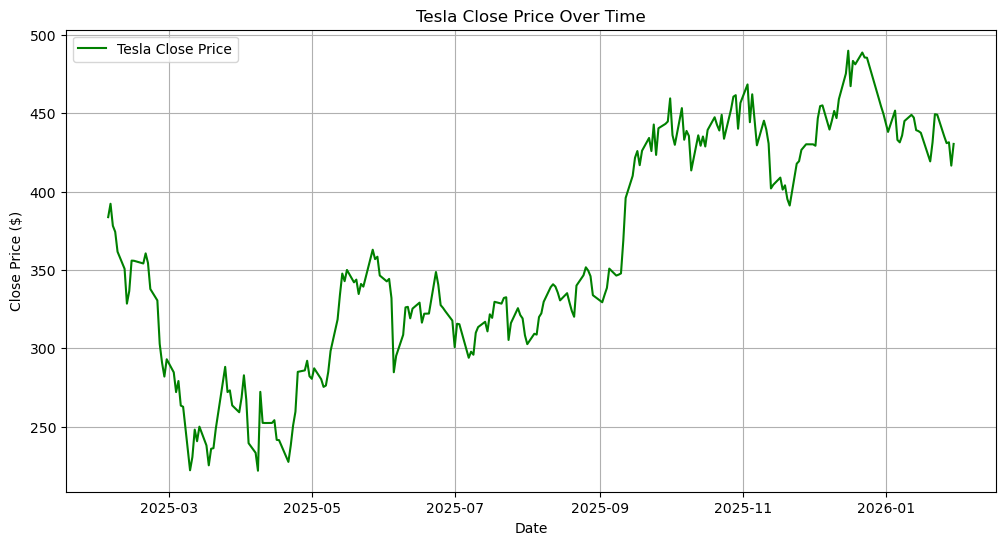

In [13]:
df_tesla['Date'] = pd.to_datetime(df_tesla['Date'])
df_tesla.set_index('Date', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df_tesla.index, df_tesla['Close'], color ='green', label='Tesla Close Price')
plt.title('Tesla Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

***DATA COMPLETETENESS***

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-02-03 00:00:00-05:00 to 2026-01-30 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          250 non-null    float64
 1   High          250 non-null    float64
 2   Low           250 non-null    float64
 3   Close         250 non-null    float64
 4   Volume        250 non-null    int64  
 5   Dividends     250 non-null    float64
 6   Stock Splits  250 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.6 KB


In [15]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02,250.0,250.0
mean,359.697000,367.190999,351.692080,359.529200,9.675513e+07,0.0,0.0
std,72.695045,72.411498,72.398878,72.206794,3.516043e+07,0.0,0.0
min,223.779999,230.100006,214.250000,221.860001,3.625290e+07,0.0,0.0
25%,308.792496,312.860008,301.057503,308.614990,7.250328e+07,0.0,0.0
50%,345.449997,351.194992,337.600006,344.044998,8.994800e+07,0.0,0.0
75%,434.857498,440.500008,425.275009,432.584991,1.120794e+08,0.0,0.0
max,489.880005,498.829987,485.329987,489.880005,2.874998e+08,0.0,0.0


In [16]:
data.shape

(250, 7)

In [17]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [18]:
print(f"The missing values in the dataset: {data['Close'].isnull().sum()}")

The missing values in the dataset: 0


In [19]:
total_rows = len(data)

missing_info = pd.DataFrame({
    'missing_count': data.isnull().sum(),
    'missing_percentage': (data.isnull().sum() / total_rows) * 100
})

print(missing_info)


              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


***DATA LATENCY***

In [20]:
min_close = data['Close'].min()
max_close = data['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 221.86000061035156
Maximum Close Price: 489.8800048828125
Difference between Max and Min Close Price: 268.02000427246094


***DATA CONSISTENCY***

In [21]:
print(data.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [22]:
print(data.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


***ERROR RATE***

In [23]:
missing_rate = data.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [24]:
duplicate_rate = data.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [25]:
Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data['Close'] < Q1 - 1.5 * IQR) | (data['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

0.0


***DATA ACCURACY***

In [26]:
minimum_price = data['Close'].min()
max_price = data['Close'].max()

print("The minimum recorded price is", minimum_price)

print("The maximum recorded price is", max_price)

The minimum recorded price is 221.86000061035156
The maximum recorded price is 489.8800048828125


In [27]:
negative_price_count = (data['Close'] < 0).sum()
print("Number of records with negative Close price:", negative_price_count)

Number of records with negative Close price: 0


In [28]:
valid_close = data['Close'] > 0
valid_volume = data['Volume'] > 0
valid_dividends = data['Dividends'].notnull()

accurate_records = data[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [29]:
invalid_records = data[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")


❌ Invalid Value Rate: 0.00%


In [30]:
duplicate_rows = data.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [31]:
unit_price_accuracy = (data['Close'] > 0).sum() / len(data) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
